In [70]:
import pandas as pd

In [71]:
pd.set_option('display.max_rows',10)

In [72]:
## importing datasets

In [73]:
sales = pd.read_csv("Sales data.csv")
inventory = pd.read_csv("Inventory.csv")

In [74]:
##checking data

In [75]:
sales.head()

,Invoice ID,Date,Category,Product,Unit Price (Naira),Quantity,Sales (Naira),Payment,COGS (Naira),Gross Income(Naira),Unnamed: 10
0,INV0001,1/1/2025,Food items,Beans,60000,3,180000,Cash,72000,216000,NaN
1,INV0002,1/1/2025,Snacks,Chips,400,5,2000,Cash,480,2400,NaN
2,INV0003,1/1/2025,Beverages,Fanta,2880,1,2880,Cash,3456,3456,NaN
3,INV0004,1/1/2025,Household,Toothpaste,800,6,4800,Cash,960,5760,NaN
4,INV0005,1/1/2025,Household,Shampoo,1200,3,3600,Card,1440,4320,NaN


In [7]:
inventory.head()

,Category,Product,Stocked,Current Stock,Re_order %,Restock_Alert
0,Beverages,Coke,1200,163,14,Stock Level OK
1,Beverages,Pepsi,1200,237,20,Stock Level OK
2,Beverages,Fanta,1200,314,26,Stock Level OK
3,Beverages,Water,1200,357,30,Stock Level OK
4,Food items,Rice,2000,66,3,Restock Alert


In [8]:
## checking top selling products

In [9]:
sales.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

Product
Rice             1934
Bread            1804
Soap             1790
Toothpaste       1674
Beans            1184
                 ... 
Earphones         153
Skipping Rope     150
Cooking Gas       149
Vitamin C         147
T-shirt           127
Name: Quantity, Length: 48, dtype: int64

In [10]:
## checking sales by category

In [76]:
sales.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

Category
Food items         9242
Household          6256
Beverages          3729
Snacks             2848
Dairy              1364
Electronics         971
Sport               920
Clothing            902
Pharmaceuticals     854
Name: Quantity, dtype: int64

In [12]:
##Low Stock Detection

In [77]:
# Filter low stock products
low_stock = inventory[inventory["Current Stock"] <= inventory["Re_order %"]]

In [78]:
# Print results
print("LOW STOCK PRODUCTS:\n")
print(low_stock[["Product", "Current Stock", "Re_order %"]])

LOW STOCK PRODUCTS:

          Product  Current Stock  Re_order %
9       Chocolate              0           0
23     Power Bank              1           1
43  Running Shoes             -1          -1


In [79]:
low_stock_sorted = low_stock.sort_values(by="Current Stock")

print("\nTOP CRITICAL LOW STOCK PRODUCTS:\n")
print(low_stock_sorted[["Product", "Current Stock", "Re_order %"]].head(10))


TOP CRITICAL LOW STOCK PRODUCTS:

          Product  Current Stock  Re_order %
43  Running Shoes             -1          -1
9       Chocolate              0           0
23     Power Bank              1           1


In [80]:
file = "Albarka Store.xlsx"

inventory = pd.read_excel(file, sheet_name="Inventory")
sales = pd.read_excel(file, sheet_name="Sales Data")

print(inventory.head())


     Category Product  Stocked  Current Stock  Re_order %   Restock_Alert
0   Beverages    Coke     1200            163   13.583333  Stock Level OK
1   Beverages   Pepsi     1200            237   19.750000  Stock Level OK
2   Beverages   Fanta     1200            314   26.166667  Stock Level OK
3   Beverages   Water     1200            357   29.750000  Stock Level OK
4  Food items    Rice     2000             66    3.300000   Restock Alert


In [81]:
## Stock alert

In [82]:
def stock_status(row):
    if row["Re_order %"] <= 5:
        return "RESTOCK ALERT"
    elif row["Re_order %"] > 50:
        return "OVERSTOCK"
    else:
        return "STOCK LEVEL OK"

inventory["STOCK STATUS"] = inventory.apply(stock_status, axis=1)

In [83]:
print(inventory[["Product", "Re_order %", "STOCK STATUS"]])

          Product  Re_order %    STOCK STATUS
0            Coke   13.583333  STOCK LEVEL OK
1           Pepsi   19.750000  STOCK LEVEL OK
2           Fanta   26.166667  STOCK LEVEL OK
3           Water   29.750000  STOCK LEVEL OK
4            Rice    3.300000   RESTOCK ALERT
..            ...         ...             ...
43  Running Shoes   -0.500000   RESTOCK ALERT
44         Coffee   21.300000  STOCK LEVEL OK
45  Phone Charger   68.600000       OVERSTOCK
46          Sugar   38.100000  STOCK LEVEL OK
47            Tea   39.900000  STOCK LEVEL OK

[48 rows x 3 columns]


In [20]:
inventory["STOCK STATUS"] = "STOCK LEVEL OK"

inventory.loc[inventory["Re_order %"] <= 5, "STOCK STATUS"] = "RESTOCK ALERT"
inventory.loc[inventory["Re_order %"] > 50, "STOCK STATUS"] = "OVERSTOCK"

In [21]:
# low stocks

In [22]:
low_stock = inventory[inventory["STOCK STATUS"] == "RESTOCK ALERT"]

print("\nLOW STOCK PRODUCTS:\n")
print(low_stock[["Product", "Re_order %", "STOCK STATUS"]])


LOW STOCK PRODUCTS:

             Product  Re_order %   STOCK STATUS
4               Rice    3.300000  RESTOCK ALERT
9          Chocolate    0.000000  RESTOCK ALERT
10             Chips    3.100000  RESTOCK ALERT
13        Toothpaste    1.529412  RESTOCK ALERT
22          LED Bulb    3.666667  RESTOCK ALERT
23        Power Bank    0.500000  RESTOCK ALERT
37  Pain Relief Balm    4.000000  RESTOCK ALERT
38       Paracetamol    3.000000  RESTOCK ALERT
42            Jersey    0.909091  RESTOCK ALERT
43     Running Shoes   -0.500000  RESTOCK ALERT


In [23]:
## Overstock alert

In [24]:
overstock = inventory[inventory["STOCK STATUS"] == "OVERSTOCK"]

print("\nOVERSTOCK PRODUCTS:\n")
print(overstock[["Product", "Re_order %", "STOCK STATUS"]])


OVERSTOCK PRODUCTS:

          Product  Re_order % STOCK STATUS
18        T-shirt   57.666667    OVERSTOCK
27         Butter   66.250000    OVERSTOCK
34    Cooking Gas   51.935484    OVERSTOCK
45  Phone Charger   68.600000    OVERSTOCK


In [25]:
print("\n🔴 LOW STOCK PRODUCTS:")
for _, row in low_stock.iterrows():
    print(f"{row['Product']} → {row['Re_order %']}%")

print("\n🟡 OVERSTOCK PRODUCTS:")
for _, row in overstock.iterrows():
    print(f"{row['Product']} → {row['Re_order %']}%")


🔴 LOW STOCK PRODUCTS:
Rice → 3.3000000000000003%
Chocolate → 0.0%
Chips → 3.1%
Toothpaste → 1.5294117647058825%
LED Bulb → 3.6666666666666665%
Power Bank → 0.5%
Pain Relief Balm → 4.0%
Paracetamol → 3.0%
Jersey → 0.9090909090909091%
Running Shoes → -0.5%

🟡 OVERSTOCK PRODUCTS:
T-shirt → 57.666666666666664%
Butter → 66.25%
Cooking Gas → 51.935483870967744%
Phone Charger → 68.60000000000001%


In [26]:
# Most critical low stock (lowest %)
low_stock_sorted = low_stock.sort_values(by="Re_order %")

print(low_stock_sorted.head(5))

       Category        Product  Stocked  Current Stock  Re_order %  \
43       Sports  Running Shoes      200             -1   -0.500000   
9        Snacks      Chocolate     1000              0    0.000000   
23  Electronics     Power Bank      200              1    0.500000   
42       Sports         Jersey      220              2    0.909091   
13    Household     Toothpaste     1700             26    1.529412   

    Restock_Alert   STOCK STATUS  
43  Restock Alert  RESTOCK ALERT  
9   Restock Alert  RESTOCK ALERT  
23  Restock Alert  RESTOCK ALERT  
42  Restock Alert  RESTOCK ALERT  
13  Restock Alert  RESTOCK ALERT  


In [27]:
# Most extreme overstock (highest %)
overstock_sorted = overstock.sort_values(by="Re_order %", ascending=False)

print(overstock_sorted.head(5))

       Category        Product  Stocked  Current Stock  Re_order %  \
45  Electronics  Phone Charger      500            343   68.600000   
27        Diary         Butter     2000           1325   66.250000   
18     Clothing        T-shirt      300            173   57.666667   
34    Household    Cooking Gas      310            161   51.935484   

      Restock_Alert STOCK STATUS  
45  Overstock Alert    OVERSTOCK  
27  Overstock Alert    OVERSTOCK  
18  Overstock Alert    OVERSTOCK  
34  Overstock Alert    OVERSTOCK  


In [28]:
#Average daily sales by product

In [29]:
sales_grouped = sales.groupby("Product")["Quantity"].mean().reset_index()
sales_grouped.rename(columns={"Quantity": "Avg Daily Sales"}, inplace=True)

In [30]:
## merging with inventory

In [31]:
inventory = inventory.merge(sales_grouped, left_on="Product", right_on="Product", how="left")

In [32]:
# predict out of stock

In [33]:
inventory["Days Remaining"] = inventory["Current Stock"] / inventory["Avg Daily Sales"]

In [34]:
## Identify urgent restock

In [35]:
urgent = inventory[inventory["Days Remaining"] < 7]

print("URGENT RESTOCK (LESS THAN 7 DAYS):")
print(urgent[["Product", "Current Stock", "Days Remaining"]])

URGENT RESTOCK (LESS THAN 7 DAYS):
             Product  Current Stock  Days Remaining
9          Chocolate              0        0.000000
10             Chips             31        5.726522
13        Toothpaste             26        4.379928
19        Wristwatch             20        4.000000
21     Extension Box             27        5.150289
..               ...            ...             ...
37  Pain Relief Balm              8        1.291667
38       Paracetamol              6        0.927835
40         Dumbbells             34        6.759036
42            Jersey              2        0.330275
43     Running Shoes             -1       -0.169154

[12 rows x 3 columns]


In [36]:
## Charts

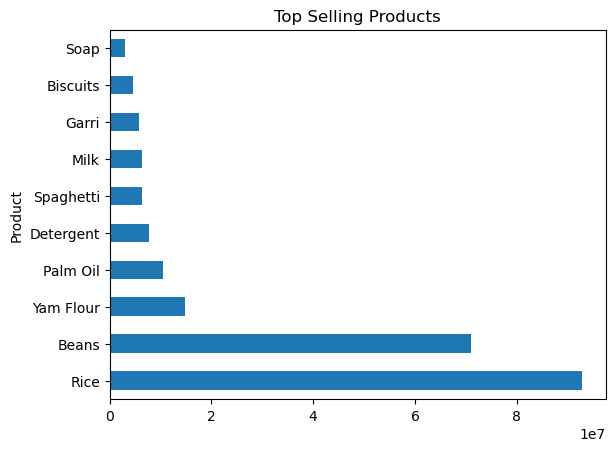

In [86]:
import matplotlib.pyplot as plt

# Top selling products
top_products = sales.groupby("Product")["Sales (Naira)"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="barh")
plt.title("Top Selling Products")
plt.show()

In [85]:
plt.figure(figsize=(10,6))



plt.title("Top Selling Products")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

NameError: name 'Product' is not defined

<Figure size 1000x600 with 0 Axes>

In [38]:
## low selling product

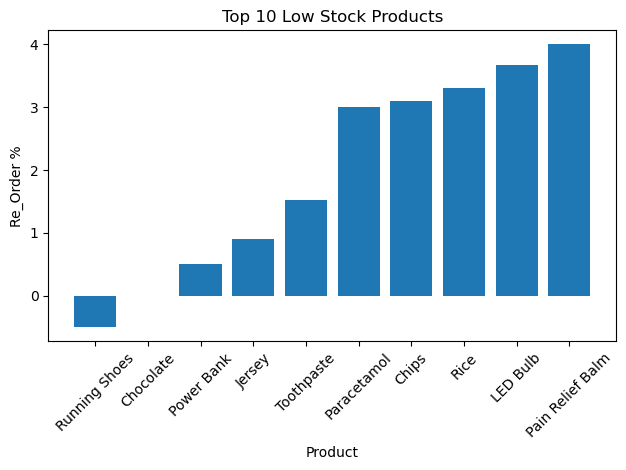

In [39]:
# Sort low stock (most critical first)
low_stock_sorted = low_stock.sort_values(by="Re_order %")

# Take top 10 worst
top_low = low_stock_sorted.head(10)

# Plot
plt.figure()
plt.bar(top_low["Product"], top_low["Re_order %"])

plt.title("Top 10 Low Stock Products")
plt.xlabel("Product")
plt.ylabel("Re_Order %")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
## Overstock product

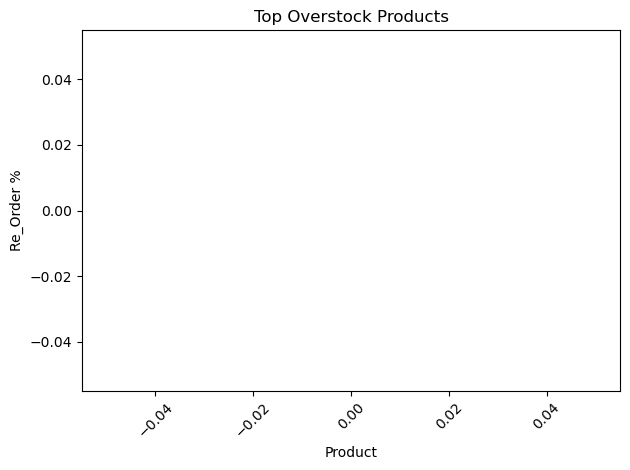

In [58]:
# Filter overstock products
overstock = inventory[inventory["Restock_Alert"] == "Overstock"]

# Sort highest first
overstock_sorted = overstock.sort_values(by="Re_order %", ascending=False)

# Take top 10
top_overstock = overstock_sorted.head(10)

# Plot
plt.figure()
plt.bar(top_overstock["Product"], top_overstock["Re_order %"])

plt.title("Top Overstock Products")
plt.xlabel("Product")
plt.ylabel("Re_Order %")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
def stock_status(row):
    if row["Re_order %"] <= 5:
        return "CRITICAL"
    elif row["Re_order %"] > 50:
        return "OVERSTOCK"
    else:
        return "OK"

inventory["Restock_Alert"] = inventory.apply(stock_status, axis=1)

In [43]:
print(inventory["Restock_Alert"].unique())

['OK' 'CRITICAL' 'OVERSTOCK']


In [44]:
# smart datasets

In [45]:
inventory.to_excel("Final_Inventory_Analysis.xlsx", index=False)

In [46]:
## Sales Trend Over Time

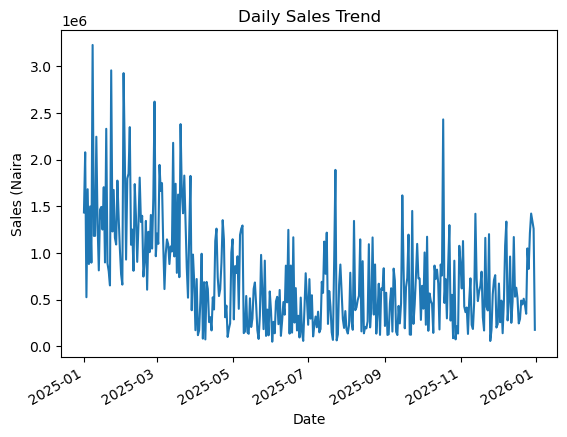

In [47]:
import matplotlib.pyplot as plt

sales["Date"] = pd.to_datetime(sales["Date"])

daily_sales = sales.groupby("Date")["Sales (Naira)"].sum()

plt.figure()
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales (Naira")
plt.show()

In [48]:
##Monthly Demand Prediction

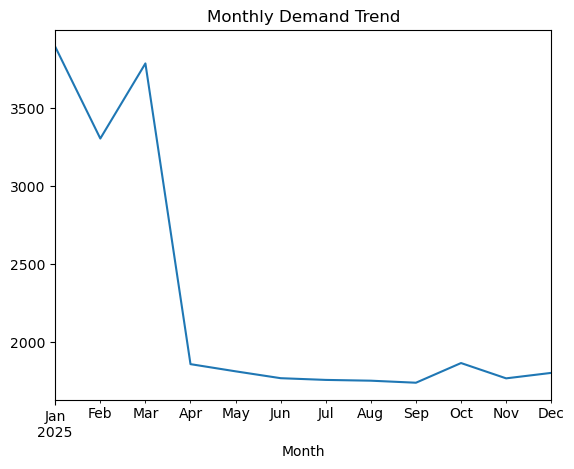

In [49]:
sales["Month"] = sales["Date"].dt.to_period("M")

monthly_sales = sales.groupby("Month")["Quantity"].sum()

plt.figure()
monthly_sales.plot(kind="line")
plt.title("Monthly Demand Trend")
plt.show()

In [50]:
##Forecast Future Sales

17:23:57 - cmdstanpy - INFO - Chain [1] start processing
17:23:59 - cmdstanpy - INFO - Chain [1] done processing


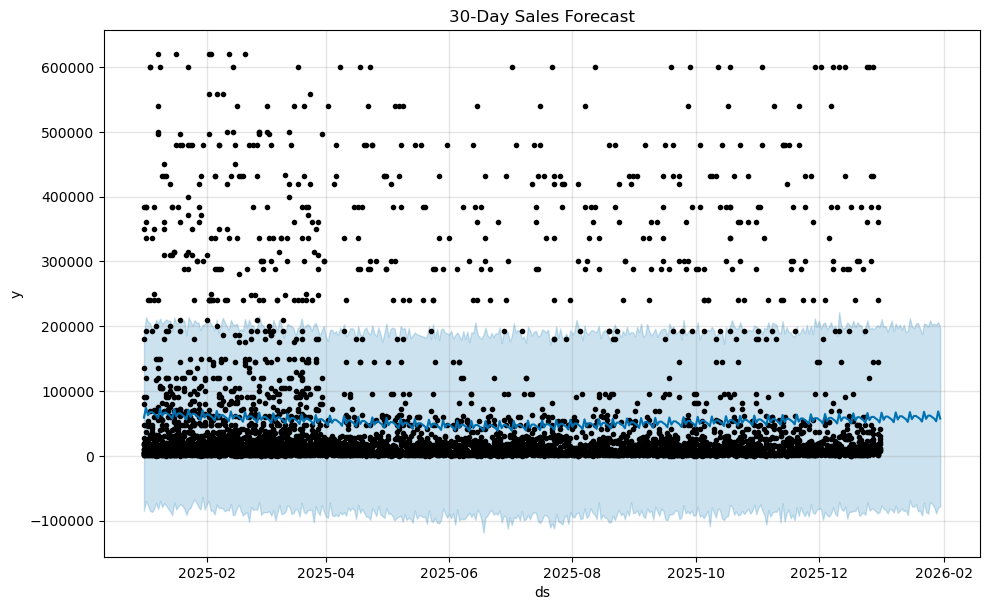

In [51]:
from prophet import Prophet

# Prepare data
df_prophet = sales[["Date", "Sales (Naira)"]]
df_prophet.columns = ["ds", "y"]

model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

model.plot(forecast)
plt.title("30-Day Sales Forecast")
plt.show()

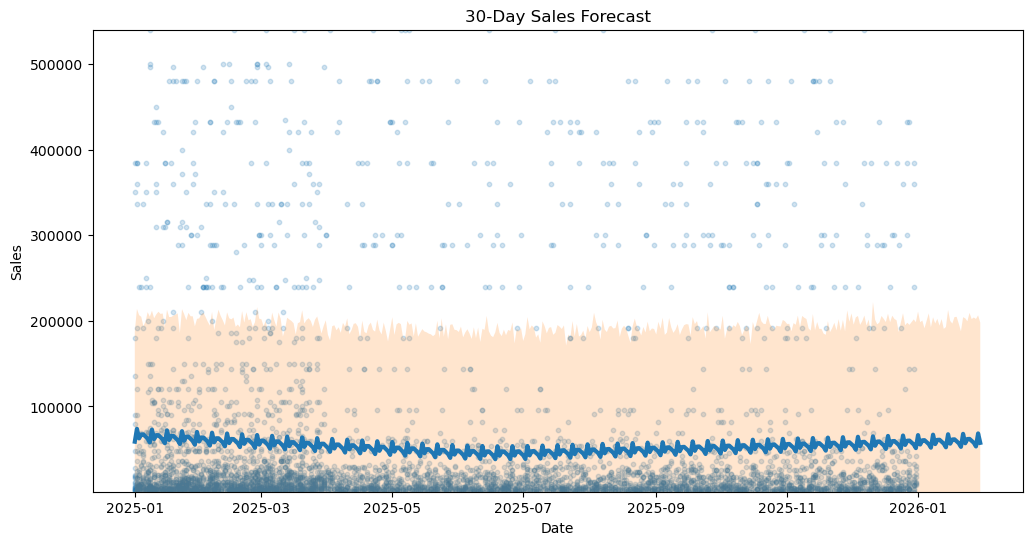

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Actual data (scatter, light)
plt.scatter(df_prophet['ds'], df_prophet['y'], alpha=0.2, s=10)

# Forecast line (bold)
plt.plot(forecast['ds'], forecast['yhat'], linewidth=3)

# Confidence interval (soft)
plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    alpha=0.2
)

# Limit axis (important!)
plt.ylim(df_prophet['y'].quantile(0.01), df_prophet['y'].quantile(0.99))

plt.title("30-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [ ]:
print(df_prophet.head())

In [ ]:
##Calculate Average Daily Sales

In [ ]:
avg_sales = sales.groupby("Product")["Quantity"].mean().reset_index()
avg_sales.rename(columns={"Quantity": "Avg Daily Sales"}, inplace=True)

In [ ]:
##Predict Days Remaining

In [ ]:
inventory["Days Remaining"] = inventory["Current Stock"] / inventory["Avg Daily Sales"]

In [ ]:
inventory = inventory.merge(
    avg_sales,
    left_on="Product",
    right_on="Product",
    how="left"
)

In [ ]:
## Smart alert

In [62]:
def smart_alert(row):
    if row["Days Remaining"] < 5:
        return "URGENT RESTOCK"
    elif row["Days Remaining"] < 10:
        return "RESTOCK SOON"
    elif row["Days Remaining"] > 30:
        return "OVERSTOCK"
    else:
        return "OK"

inventory["SMART ALERT"] = inventory.apply(smart_alert, axis=1)

In [63]:
##Results

In [64]:
print(inventory[["Product", "Current Stock", "Days Remaining", "SMART ALERT"]])

          Product  Current Stock  Days Remaining     SMART ALERT
0            Coke            163       30.336548       OVERSTOCK
1           Pepsi            237       43.068536       OVERSTOCK
2           Fanta            314       58.121896       OVERSTOCK
3           Water            357       70.298932       OVERSTOCK
4            Rice             66       12.012410              OK
..            ...            ...             ...             ...
43  Running Shoes             -1       -0.169154  URGENT RESTOCK
44         Coffee            213       37.890724       OVERSTOCK
45  Phone Charger            343       69.910828       OVERSTOCK
46          Sugar            381       68.936995       OVERSTOCK
47            Tea            399       75.683860       OVERSTOCK

[48 rows x 4 columns]


In [65]:
inventory[["Product", "Current Stock", "Days Remaining", "SMART ALERT"]]


,Product,Current Stock,Days Remaining,SMART ALERT
0,Coke,163,30.336548,OVERSTOCK
1,Pepsi,237,43.068536,OVERSTOCK
2,Fanta,314,58.121896,OVERSTOCK
3,Water,357,70.298932,OVERSTOCK
4,Rice,66,12.012410,OK
...,...,...,...,...
43,Running Shoes,-1,-0.169154,URGENT RESTOCK
44,Coffee,213,37.890724,OVERSTOCK
45,Phone Charger,343,69.910828,OVERSTOCK
46,Sugar,381,68.936995,OVERSTOCK


In [66]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [67]:
inventory[["Product", "Current Stock", "Days Remaining", "SMART ALERT"]]

,Product,Current Stock,Days Remaining,SMART ALERT
0,Coke,163,30.336548,OVERSTOCK
1,Pepsi,237,43.068536,OVERSTOCK
2,Fanta,314,58.121896,OVERSTOCK
3,Water,357,70.298932,OVERSTOCK
4,Rice,66,12.012410,OK
5,Beans,816,150.932432,OVERSTOCK
6,Bread,196,36.831486,OVERSTOCK
7,Spaghetti,131,23.160898,OK
8,Biscuits,121,23.539249,OK
9,Chocolate,0,0.000000,URGENT RESTOCK


In [60]:
sorted_table = inventory.sort_values(by="Days Remaining")

sorted_table = sorted_table[[
    "Product",
    "Current Stock",
    "Days Remaining",
    "SMART ALERT"
]]

sorted_table.reset_index(drop=True, inplace=True)

sorted_table

KeyError: "['SMART ALERT'] not in index"

In [68]:
sorted_table.head(10)

,Category,Product,Stocked,Current Stock,Re_order %,Restock_Alert,STOCK STATUS,Avg Daily Sales,Days Remaining
43,Sports,Running Shoes,200,-1,-0.500000,CRITICAL,RESTOCK ALERT,5.911765,-0.169154
9,Snacks,Chocolate,1000,0,0.000000,CRITICAL,RESTOCK ALERT,5.076142,0.000000
23,Electronics,Power Bank,200,1,0.500000,CRITICAL,RESTOCK ALERT,5.852941,0.170854
42,Sports,Jersey,220,2,0.909091,CRITICAL,RESTOCK ALERT,6.055556,0.330275
38,Pharmaceuticals,Paracetamol,200,6,3.000000,CRITICAL,RESTOCK ALERT,6.466667,0.927835
37,Pharmaceuticals,Pain Relief Balm,200,8,4.000000,CRITICAL,RESTOCK ALERT,6.193548,1.291667
22,Electronics,LED Bulb,300,11,3.666667,CRITICAL,RESTOCK ALERT,6.422222,1.712803
19,Clothing,Wristwatch,200,20,10.000000,OK,STOCK LEVEL OK,5.000000,4.000000
13,Household,Toothpaste,1700,26,1.529412,CRITICAL,RESTOCK ALERT,5.936170,4.379928
21,Electronics,Extension Box,200,27,13.500000,OK,STOCK LEVEL OK,5.242424,5.150289
